<a href="https://colab.research.google.com/github/Marzena-Cicha/AI/blob/main/AI_Lab5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
import pandas as pd

from keras.callbacks import EarlyStopping
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import Dense, LSTM, Dropout, GRU, Bidirectional, Input
from keras.optimizers import SGD,Adam
import math
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from keras.losses import Huber


In [ ]:
def plot_predictions(test,predicted):
  plt.plot(test, color='red',label='Real IMB Stock Price')
  plt.plot(predicted, color='blue',label='Predicted IMB Stock Price')
  plt.title('IMB Stock Price Prediction')
  plt.xlabel('Time')
  plt.ylabel('IMB Stock Price')
  plt.legend()
  plt.show()

In [ ]:
def return_rmse (test, predicted):

  rmse = math.sqrt(mean_squared_error(test, predicted))
  print('-' *30)
  print("Bład średniokwadratowy modelu {:.2f}:".format(rmse))
  print('-' *30)

def return_mae (test, predicted):
  mae = mean_absolute_error(test, predicted)
  mape = mean_absolute_perctentage_error(test, predicted) *100
  print("Sredni błąd bezwzględny: {:.2f}.".format(mae))
  print("Średni błąd bezwzględny procentowy: {:.2f}%".format(mape))
  print('-' *30)

In [ ]:
dataset = pd.read_csv('IBM_2006-01-01_to_2018-01-01.csv', index_col='Date', parse_dates=['Date'])
dataset.head()

,Open,High,Low,Close,Volume,Name
Date,,,,,,
2006-01-03,82.45,82.55,80.81,82.06,11715200,IBM
2006-01-04,82.20,82.50,81.33,81.95,9840600,IBM
2006-01-05,81.40,82.90,81.00,82.50,7213500,IBM
2006-01-06,83.95,85.03,83.41,84.95,8197400,IBM
2006-01-09,84.10,84.25,83.38,83.73,6858200,IBM


In [ ]:
training_set = dataset[:'2016'].iloc[:,1:2].values
test_set = dataset['2017':].iloc[:,1:2].values


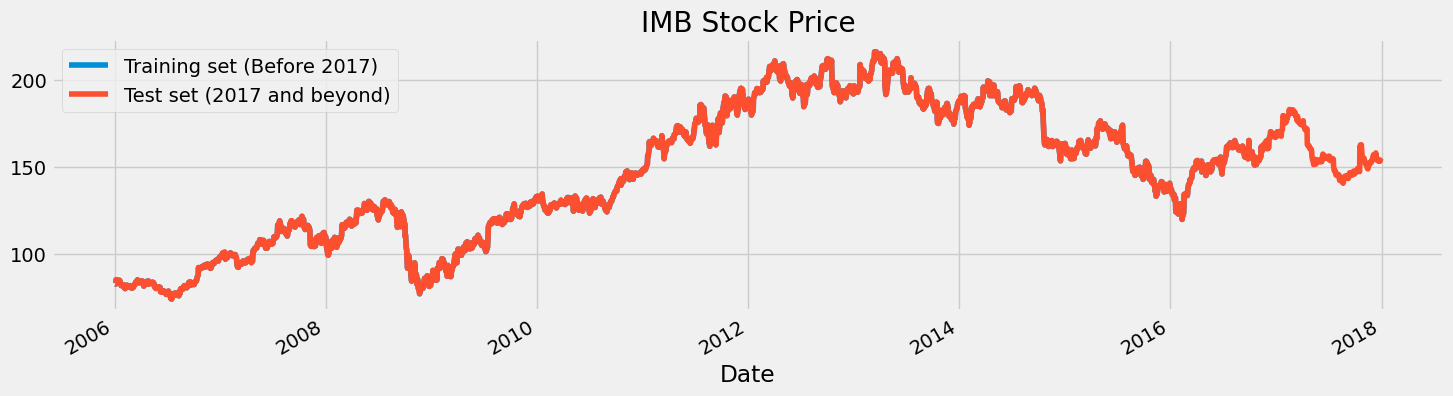

In [ ]:
dataset["High"][:'2016'].plot(figsize=(16,4), legend = True)
dataset["High"][:'2017'].plot(figsize=(16,4), legend = True)
plt.legend(['Training set (Before 2017)','Test set (2017 and beyond)'])
plt.title('IMB Stock Price')
plt.show()


In [ ]:
sc = MinMaxScaler(feature_range=(0,1))
training_set_scaled = sc.fit_transform(training_set)

In [ ]:
X_train = []
y_train = []
for i in range(60,2769):
  X_train.append(training_set_scaled[i-60:i,0])
  y_train.append(training_set_scaled[i,0])
X_train, y_train = np.array(X_train), np.array(y_train)

In [ ]:
X_train = np.reshape(X_train,(X_train.shape[0],X_train.shape[1],1))


In [ ]:
regressor = Sequential()
regressor.add(Input(shape=(X_train.shape[1],1)))
regressor.add(LSTM(units=50,return_sequences=True))
regressor.add(Dropout(0.2))

regressor.add(LSTM(units=50,return_sequences=True))
regressor.add(Dropout(0.2))

regressor.add(LSTM(units=50,return_sequences=True))
regressor.add(Dropout(0.2))

regressor.add(LSTM(units=50))
regressor.add(Dropout(0.2))
regressor.add(Dense(units=1))

regressor.compile(optimizer='rmsprop',loss='mean_squared_error')
regressor.fit(X_train,y_train,epochs=50,batch_size=32)

Epoch 1/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 18s 113ms/step - loss: 0.0214
Epoch 2/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 10s 114ms/step - loss: 0.0108
Epoch 3/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 9s 107ms/step - loss: 0.0084
Epoch 4/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 9s 103ms/step - loss: 0.0072
Epoch 5/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 10s 112ms/step - loss: 0.0063
Epoch 6/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 11s 118ms/step - loss: 0.0058
Epoch 7/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 9s 101ms/step - loss: 0.0048
Epoch 8/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 9s 110ms/step - loss: 0.0049
Epoch 9/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 10s 116ms/step - loss: 0.0044
Epoch 10/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 10s 113ms/step - loss: 0.0042
Epoch 11/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 9s 97ms/step - loss: 0.0037
Epoch 12/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 10s 112ms/step - loss: 0.0036
Epoch 13/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 10s 112ms/step - loss: 0.0038
Epoch 14/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 9s 110ms/step - loss: 0.0034
Epoch 15/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 9s 99ms/ste

In [ ]:
dataset_total = pd.concat((dataset["High"][:'2016'],dataset["High"]['2017':]),axis=0)
inputs = dataset_total[len(dataset_total)-len(test_set)-60:].values
inputs = inputs.reshape(-1,1)
inputs = sc.transform(inputs)